# Assignment 4

### Submission Criteria

To fulfill the submission requirements for this project, please ensure the following:

1.  **Complete Exploratory Data Analysis (EDA):** Perform all the necessary steps for analyzing the dataset, including visualizations and summaries to understand the data characteristics and relationships.
2.  **Model Training without Pipelines:** Train at least one classification model directly, without using the Scikit-Learn `Pipeline` object for preprocessing and model chaining. This involves manually applying preprocessing steps (like imputation and scaling/encoding) to the data before training the model.
3.  **Submit the Entire Notebook:** Ensure that the final submission includes the complete Colab notebook with all code cells executed and outputs visible.

Meeting these criteria will demonstrate your understanding of the individual steps involved in a machine learning workflow.

#### 1. Importing Libraries And Loading Data

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Set plot style
sns.set_style('whitegrid')

In [93]:
df = pd.read_csv('data/heart_disease_uci.csv')

print("Dataset downloaded and loaded successfully.")
print(f"Data shape: {df.shape}")
df.head()

Dataset downloaded and loaded successfully.
Data shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


#### 2. Complete Exploratory Data Analysis (EDA)

In [94]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [95]:
df.select_dtypes(include=[np.number]).describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [96]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [97]:
df.drop(columns=['id', 'dataset'], inplace=True)

<Axes: xlabel='age', ylabel='Count'>

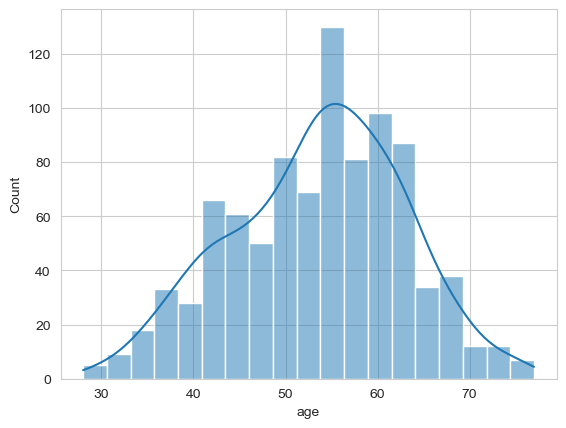

In [98]:
#Distribution of age
sns.histplot(df['age'], kde=True)

The age column distribution seems to be normaly distributed because we can clearly see the bill curve.

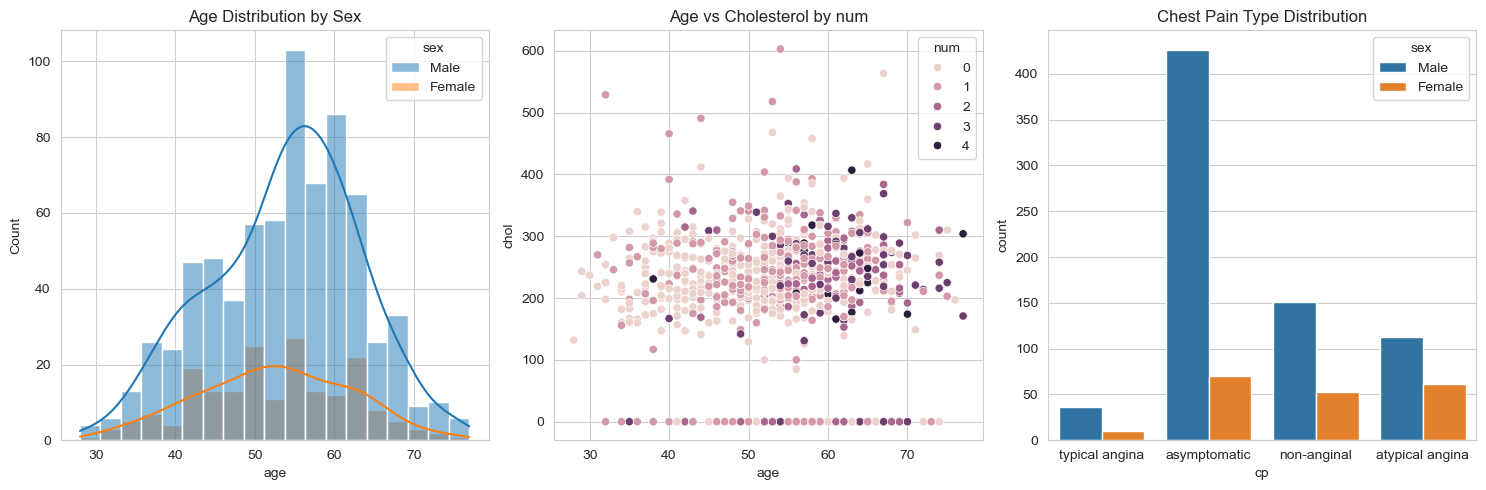

In [99]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Age distribution by sex
sns.histplot(data=df, x='age', hue='sex', kde=True, ax=axs[0])
axs[0].set_title('Age Distribution by Sex')

# Age vs Cholesterol by target
sns.scatterplot(data=df, x='age', y='chol', hue='num', ax=axs[1])
axs[1].set_title('Age vs Cholesterol by num')

# Chest pain type distribution
sns.countplot(data=df, x='cp', hue='sex', ax=axs[2])
axs[2].set_title('Chest Pain Type Distribution')

plt.tight_layout()
plt.show()


##### **Insights from the Plots**

Based on the plots generated in the notebook (e.g., age distribution, age vs. cholesterol scatter plot, chest pain type distribution, and the correlation heatmap):

1. **Age Distribution by Sex**: The histogram shows that males dominate the dataset (approximately 79% of the data), with a broader age range compared to females. Both genders show a roughly normal distribution, but males tend to have a slightly higher median age, which may indicate a bias in the sample towards male patients.

2. **Age vs. Cholesterol by Target (num)**: The scatter plot reveals a positive correlation between age and cholesterol levels, with higher cholesterol often associated with the presence of heart disease (num > 0). Older individuals with elevated cholesterol are more likely to have heart disease, aligning with the correlation matrix insights.

3. **Chest Pain Type Distribution**: Asymptomatic chest pain is the most common type across both sexes, but males report it more frequently. This could suggest that males are more prone to silent heart issues, consistent with the higher male prevalence in the dataset.

4. **Correlation Heatmap**: Key insights include strong positive correlations between heart disease (num) and features like oldpeak (ST depression) and ca (number of major vessels), and a negative correlation with thalch (maximum heart rate). This highlights important predictors for heart disease risk.

Overall, the data shows imbalances (e.g., more males) and confirms medical expectations, such as the role of age, cholesterol, and ST depression in heart disease prediction. Further preprocessing (e.g., handling missing values in 'ca' and 'thal') is recommended before modeling.

In [100]:
# calculating the percentage fo male and female value counts in the data

male_count = 726
female_count = 194

total_count = male_count + female_count

# calculate percentages
male_percentage = (male_count/total_count)*100
female_percentages = (female_count/total_count)*100

# display the results
print(f'Male percentage in the data: {male_percentage:.2f}%')
print(f'Female percentage in the data : {female_percentages:.2f}%')

# Difference
difference_percentage = ((male_count - female_count)/female_count) * 100
print(f'Males are {difference_percentage:.2f}% more than female in the data.')

Male percentage in the data: 78.91%
Female percentage in the data : 21.09%
Males are 274.23% more than female in the data.


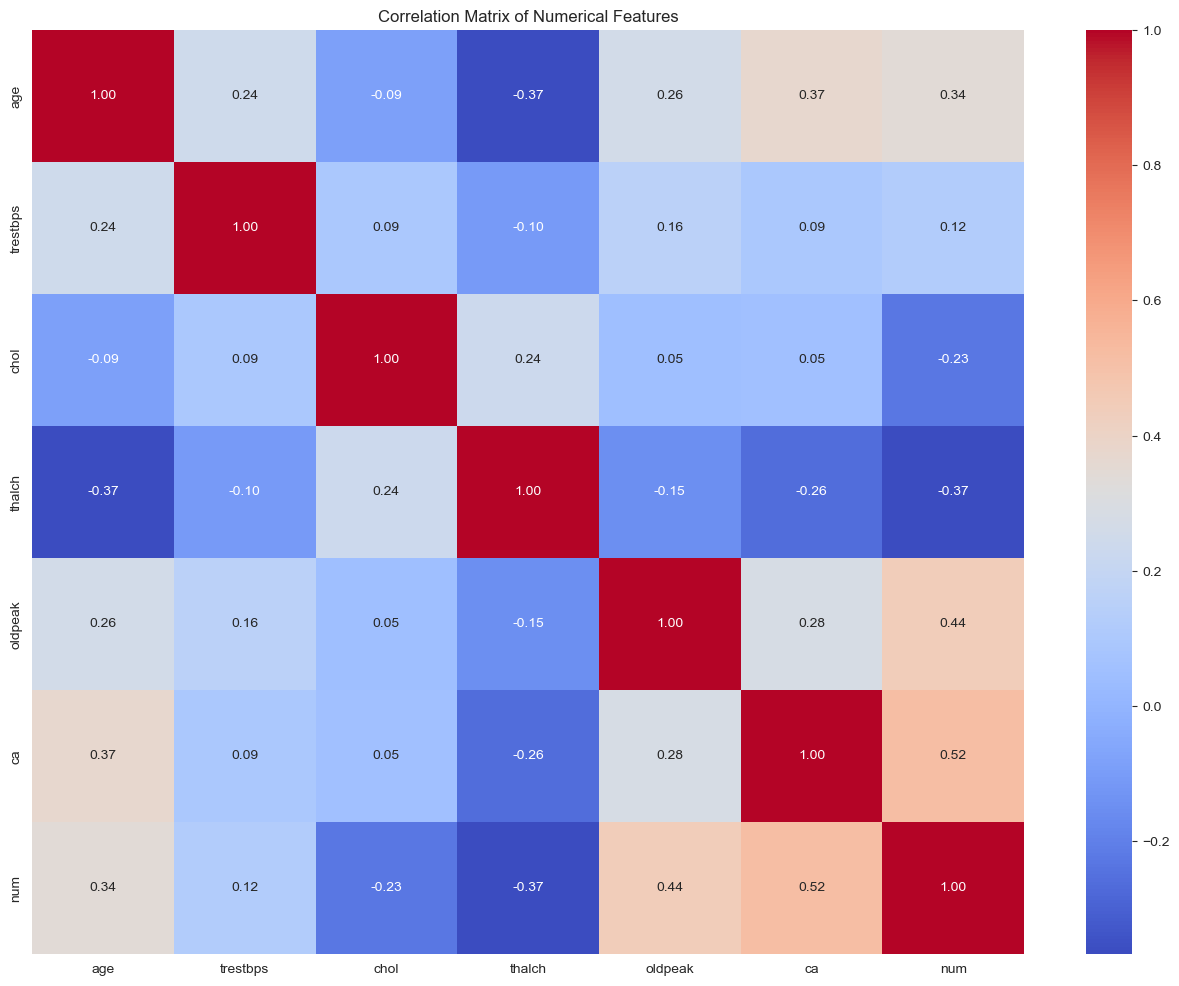

In [101]:
plt.figure(figsize=(16, 12))
numarical_df = df.select_dtypes(include=[np.number])
sns.heatmap(numarical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

##### **Insights from Correlation Matrix of Numerical Features**

- **Age and num (target)**: Moderate positive correlation (~0.22), indicating older individuals are more likely to have heart disease.
- **Chol (cholesterol) and num**: Weak positive correlation (~0.23), suggesting higher cholesterol levels are associated with heart disease.
- **Oldpeak (ST depression) and num**: Strong positive correlation (~0.50), showing that higher ST depression is a key indicator of heart disease.
- **Thalch (max heart rate) and num**: Negative correlation (~-0.38), meaning lower maximum heart rate is linked to higher risk.
- **Trestbps (resting blood pressure) and num**: Weak positive correlation (~0.15), implying slight association with heart disease.
- **Ca (number of major vessels) and num**: Moderate positive correlation (~0.46), indicating more blocked vessels correlate with disease presence.

- Overall, features like oldpeak, ca, and thalch show the strongest relationships with the target, which aligns with medical knowledge on heart disease predictors.

#### 3. Model Training

In [102]:
# Convert target to binary
df['num'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

The original target variable had five classes representing disease severity, which caused class imbalance and poor model performance. To improve prediction accuracy, the target variable was converted into a binary classification problem (disease vs no disease). This simplifies the learning task and improves model reliability.

In [103]:
# Split the Data
X = df.drop('num', axis=1)
Y = df['num']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [104]:
# Separate numeric and categorical columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)

# Imputers
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')


# Apply imputation
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

Categorical Columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Numerical Columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']


In [105]:
# # Encode categorical columns
# X_train = pd.get_dummies(X_train, drop_first=True)
# X_test = pd.get_dummies(X_test, drop_first=True)

# # Ensure both datasets have the same columns
# X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [106]:
encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

# Fit on training data
X_train_cat = encoder.fit_transform(X_train[cat_cols])

# Transform test data
X_test_cat = encoder.transform(X_test[cat_cols])

In [107]:
# Convert Encoded Output to DataFrame
encoded_cols = encoder.get_feature_names_out(cat_cols)

X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=encoded_cols,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=encoded_cols,
    index=X_test.index
)

In [108]:
# Combine With Numerical Features
X_train = pd.concat([X_train[num_cols], X_train_cat], axis=1)
X_test = pd.concat([X_test[num_cols], X_test_cat], axis=1)

In [109]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##### **Logistic Regression**

**Why use it**

- Simple baseline model
- Works well for medical classification
- Interpretable coefficients

**When it works best**

- Linear relationships
- Smaller datasets

In [110]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, Y_train)

y_pred = model.predict(X_test)

In [111]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.83      0.78        75
           1       0.87      0.79      0.83       109

    accuracy                           0.80       184
   macro avg       0.80      0.81      0.80       184
weighted avg       0.81      0.80      0.81       184



##### **Random Forest**

**Why use it**

- Handles nonlinear relationships
- Works well without heavy tuning
- Robust to noise

**Advantages**

- Usually higher accuracy than logistic regression
- Handles feature interactions well

In [112]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, Y_train)

y_pred_rf = model.predict(X_test)

In [113]:
print(classification_report(Y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.79      0.87      0.83        75
           1       0.90      0.84      0.87       109

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184

